# 1. Tech Challenge - Objetivo

**Contexto de negócio:** este projeto foi desenvolvido para um hospital que deseja um modelo de Machine Learning capaz de prever o nível de obesidade de um paciente a partir de hábitos alimentares, atividade física e dados antropométricos, apoiando a equipe médica na priorização de cuidado e orientação preventiva.

**Atenção metodológica:** o alvo (`ds_nivel_obesidade`) é derivado do dataset público *Estimation of obesity levels* (UCI), cujo rótulo original é calculado a partir de faixas de IMC (peso / altura²). `nr_altura` e `nr_peso` (e, por extensão, o próprio IMC) podem determinar quase completamente o alvo — por isso as novas features desta versão foram desenhadas para capturar hábito e comportamento, não para recombinar `nr_altura`/`nr_peso`, evitando reforçar essa circularidade.

## 2. Importação das bibliotecas

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append("..")
from src.data_processing import (
    arredondar_colunas_ordinais,
    carregar_dados_brutos,
    converter_flags_binarias,
    criar_features_comportamentais,
    remover_duplicatas_exatas,
)

## 3. Configurações iniciais

Definimos aqui o caminho do dataset bruto, a semente, a ordem lógica (do menor para o maior nível de obesidade) usada em todos os gráficos que envolvem a variável alvo, o mapeamento de nomes de colunas para nomes descritivos (prefixos `cd_` para códigos/escalas, `ds_` para categóricas descritivas, `fl_` para flags sim/não e `nr_` para numéricas contínuas, aplicado logo na leitura dos dados), e configurações de exibição/estilo para manter os gráficos consistentes ao longo do notebook.

In [2]:
SEED = 42
CAMINHO_DADOS_BRUTOS = "../data/bronze/Obesity.csv"

ORDEM_NIVEIS_OBESIDADE = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

MAPA_RENOMEACAO_COLUNAS = {
    "Gender": "ds_genero",
    "Age": "nr_idade",
    "Height": "nr_altura",
    "Weight": "nr_peso",
    "family_history": "fl_historico_familiar_sobrepeso",
    "FAVC": "fl_consumo_calorico_frequente",
    "FCVC": "cd_consumo_de_vegetais",
    "NCP": "cd_numero_refeicoes_principais",
    "CAEC": "ds_lanches_entre_refeicoes",
    "SMOKE": "fl_fumante",
    "CH2O": "cd_consumo_agua",
    "SCC": "fl_monitora_calorias",
    "FAF": "cd_frequencia_atividade_fisica",
    "TUE": "cd_tempo_uso_eletronicos",
    "CALC": "ds_consumo_alcool",
    "MTRANS": "ds_meio_transporte",
    "Obesity": "ds_nivel_obesidade",
}

COLUNAS_NUMERICAS = [
    "nr_idade",
    "nr_altura",
    "nr_peso",
    "cd_consumo_de_vegetais",
    "cd_numero_refeicoes_principais",
    "cd_consumo_agua",
    "cd_frequencia_atividade_fisica",
    "cd_tempo_uso_eletronicos",
]
COLUNAS_ORDINAIS_ARREDONDAR = [
    "cd_consumo_de_vegetais",
    "cd_numero_refeicoes_principais",
    "cd_consumo_agua",
    "cd_frequencia_atividade_fisica",
    "cd_tempo_uso_eletronicos",
]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")
np.random.seed(SEED)

## 4. Leitura dos dados

Usamos aqui as funções `carregar_dados_brutos` (aplica o `MAPA_RENOMEACAO_COLUNAS` definido na seção anterior) e `converter_flags_binarias` (transforma as colunas `fl_` de yes/no para 1/0), ambas em `src/data_processing.py`. A conversão das flags acontece logo após a leitura, antes de qualquer outra limpeza, para que nenhuma coluna `fl_` fique armazenada como texto a partir daqui.

In [3]:
pacientes_obesidade = carregar_dados_brutos(CAMINHO_DADOS_BRUTOS, MAPA_RENOMEACAO_COLUNAS)
pacientes_obesidade = converter_flags_binarias(pacientes_obesidade)

pacientes_obesidade.shape

(2111, 17)

In [4]:
pacientes_obesidade.head()

,ds_genero,nr_idade,nr_altura,nr_peso,fl_historico_familiar_sobrepeso,fl_consumo_calorico_frequente,cd_consumo_de_vegetais,cd_numero_refeicoes_principais,ds_lanches_entre_refeicoes,fl_fumante,cd_consumo_agua,fl_monitora_calorias,cd_frequencia_atividade_fisica,cd_tempo_uso_eletronicos,ds_consumo_alcool,ds_meio_transporte,ds_nivel_obesidade
0,Female,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 5. Análise exploratória

### 5.1 Tipos de dados, valores nulos e duplicatas

Sobre os 24 duplicados: serão removidos porque os valores contínuos nessas linhas não têm o ruído decimal característico do resto da base, indicando registro repetido e não paciente distinto. Além disso, é só 1,14% da base, então o impacto no modelo é pequeno de qualquer jeito; mas manter esses duplicados infla artificialmente o peso de algumas combinações específicas de hábito/perfil sem agregar sinal novo.

In [5]:
pacientes_obesidade.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ds_genero                        2111 non-null   str    
 1   nr_idade                         2111 non-null   float64
 2   nr_altura                        2111 non-null   float64
 3   nr_peso                          2111 non-null   float64
 4   fl_historico_familiar_sobrepeso  2111 non-null   int64  
 5   fl_consumo_calorico_frequente    2111 non-null   int64  
 6   cd_consumo_de_vegetais           2111 non-null   float64
 7   cd_numero_refeicoes_principais   2111 non-null   float64
 8   ds_lanches_entre_refeicoes       2111 non-null   str    
 9   fl_fumante                       2111 non-null   int64  
 10  cd_consumo_agua                  2111 non-null   float64
 11  fl_monitora_calorias             2111 non-null   int64  
 12  cd_frequencia_atividade_fisica 

In [6]:
quantidade_nulos = pacientes_obesidade.isna().sum()
quantidade_nulos

ds_genero                          0
nr_idade                           0
nr_altura                          0
nr_peso                            0
fl_historico_familiar_sobrepeso    0
fl_consumo_calorico_frequente      0
cd_consumo_de_vegetais             0
cd_numero_refeicoes_principais     0
ds_lanches_entre_refeicoes         0
fl_fumante                         0
cd_consumo_agua                    0
fl_monitora_calorias               0
cd_frequencia_atividade_fisica     0
cd_tempo_uso_eletronicos           0
ds_consumo_alcool                  0
ds_meio_transporte                 0
ds_nivel_obesidade                 0
dtype: int64

In [7]:
quantidade_duplicatas = pacientes_obesidade.duplicated().sum()

print(f"Quantidade duplicadas: {quantidade_duplicatas}")
print(f"Pct duplicadas: {quantidade_duplicatas / len(pacientes_obesidade) * 100:.2f}%")

Quantidade duplicadas: 24
Pct duplicadas: 1.14%


In [8]:
duplicadas = pacientes_obesidade[pacientes_obesidade.duplicated(keep=False)]
duplicadas

,ds_genero,nr_idade,nr_altura,nr_peso,fl_historico_familiar_sobrepeso,fl_consumo_calorico_frequente,cd_consumo_de_vegetais,cd_numero_refeicoes_principais,ds_lanches_entre_refeicoes,fl_fumante,cd_consumo_agua,fl_monitora_calorias,cd_frequencia_atividade_fisica,cd_tempo_uso_eletronicos,ds_consumo_alcool,ds_meio_transporte,ds_nivel_obesidade
97,Female,21.0,1.52,42.0,0,0,3.0,1.0,Frequently,0,1.0,0,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,0,0,3.0,1.0,Frequently,0,1.0,0,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
105,Female,25.0,1.57,55.0,0,1,2.0,1.0,Sometimes,0,2.0,0,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
106,Female,25.0,1.57,55.0,0,1,2.0,1.0,Sometimes,0,2.0,0,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
145,Male,21.0,1.62,70.0,0,1,2.0,1.0,no,0,3.0,0,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
174,Male,21.0,1.62,70.0,0,1,2.0,1.0,no,0,3.0,0,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,0,1,2.0,1.0,no,0,3.0,0,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,0,1,2.0,1.0,no,0,3.0,0,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
208,Female,22.0,1.69,65.0,1,1,2.0,3.0,Sometimes,0,2.0,0,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
209,Female,22.0,1.69,65.0,1,1,2.0,3.0,Sometimes,0,2.0,0,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight


### 5.2 Estatísticas descritivas — nr_idade, nr_altura e nr_peso

Essas três variáveis são a base do IMC e merecem um olhar dedicado antes das demais numéricas. Aqui já percebemos uma discrepância na amostra dos dados de Idade, com 75% da base tendo até 26 anos.

In [9]:
pacientes_obesidade[["nr_idade", "nr_altura", "nr_peso"]].describe().T

,count,mean,std,min,25%,50%,75%,max
nr_idade,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
nr_altura,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
nr_peso,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00


### 5.3 Distribuição da variável alvo (ds_nivel_obesidade)

Checamos aqui se as classes de obesidade estão balanceadas — isso impacta diretamente a escolha de métricas e da estratégia de validação (split estratificado, F1-macro em vez de apenas accuracy).
É uma base relativamente balanceada. No entanto, como vamos deployar o modelo, e a base pode mudar com o tempo/versões, também vamos balancear as quantidades na etapa de modelagem.

In [10]:
distribuicao_alvo = pacientes_obesidade["ds_nivel_obesidade"].value_counts().reindex(ORDEM_NIVEIS_OBESIDADE)
percentual_alvo = (distribuicao_alvo / len(pacientes_obesidade) * 100).round(2)

pd.DataFrame({"qtd_pacientes": distribuicao_alvo, "percentual": percentual_alvo})

,qtd_pacientes,percentual
ds_nivel_obesidade,,
Insufficient_Weight,272,12.88
Normal_Weight,287,13.60
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Obesity_Type_I,351,16.63
Obesity_Type_II,297,14.07
Obesity_Type_III,324,15.35


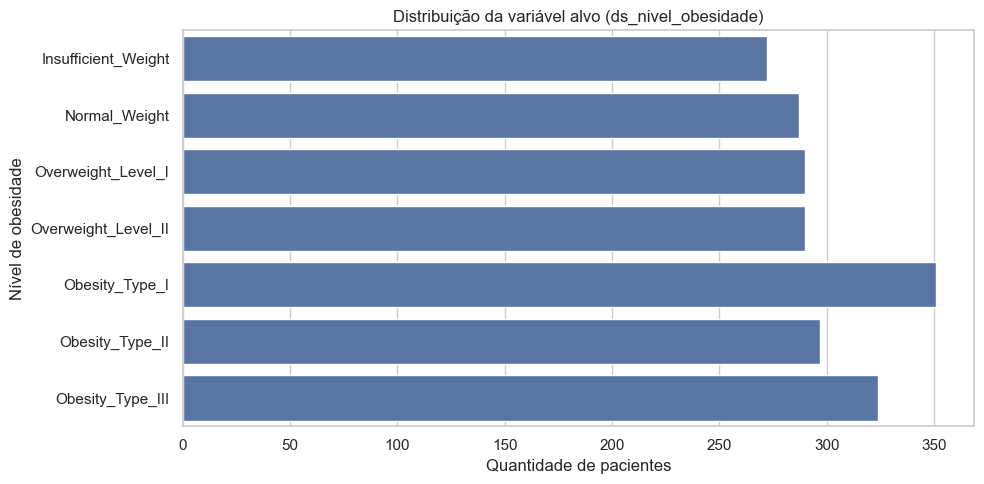

In [11]:
fig, eixo = plt.subplots(figsize=(10, 5))
sns.barplot(x=distribuicao_alvo.values, y=distribuicao_alvo.index, order=ORDEM_NIVEIS_OBESIDADE, ax=eixo)
eixo.set_title("Distribuição da variável alvo (ds_nivel_obesidade)")
eixo.set_xlabel("Quantidade de pacientes")
eixo.set_ylabel("Nível de obesidade")
plt.tight_layout()
plt.show()

### 5.4 Histogramas das variáveis numéricas

Olhamos a forma da distribuição de cada variável numérica. Os ruídos decimais das colunas `cd_consumo_de_vegetais`, `cd_numero_refeicoes_principais`, `cd_consumo_agua`, `cd_frequencia_atividade_fisica` e `cd_tempo_uso_eletronicos` serão tratados na seção de Limpeza. Além disso, novamente vemos que a base não trouxe uma amostra balanceada da idade (ela forma uma cauda, então, mais que outlier, está desbalanceado mesmo).

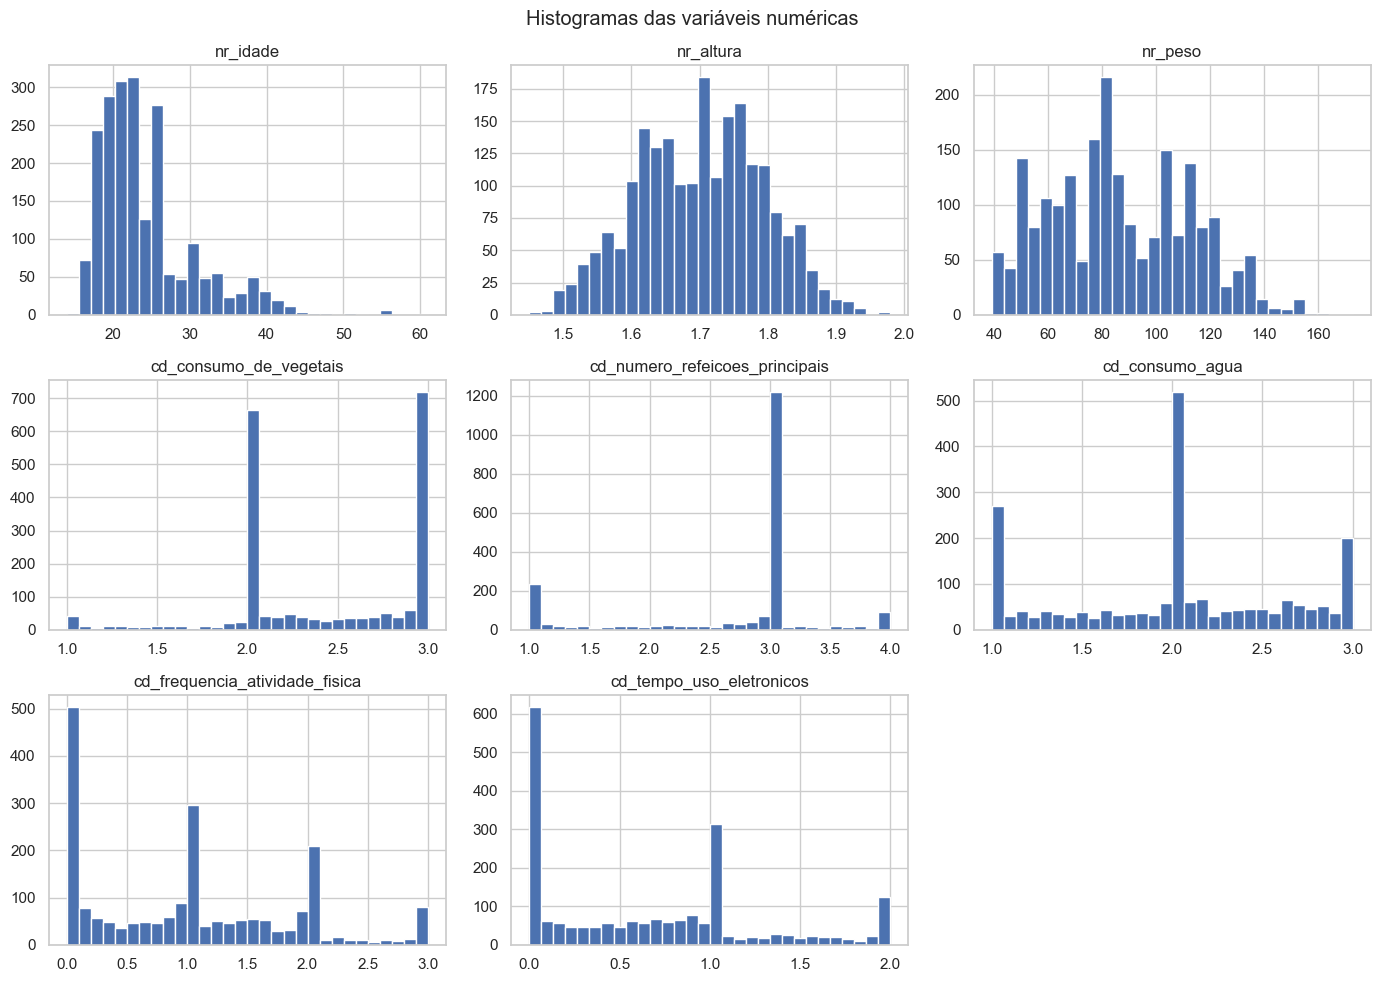

In [12]:
pacientes_obesidade[COLUNAS_NUMERICAS].hist(figsize=(14, 10), bins=30)
plt.suptitle("Histogramas das variáveis numéricas")
plt.tight_layout()
plt.show()

### 5.5 Boxplots das variáveis numéricas

Usados para identificar outliers e comparar a dispersão entre as variáveis. Optamos por não mexer nos outliers de idade, peso e altura, visto que a variedade é importante para a análise hospitalar. As outras variáveis são categóricas, dispensado o controle de outliers.

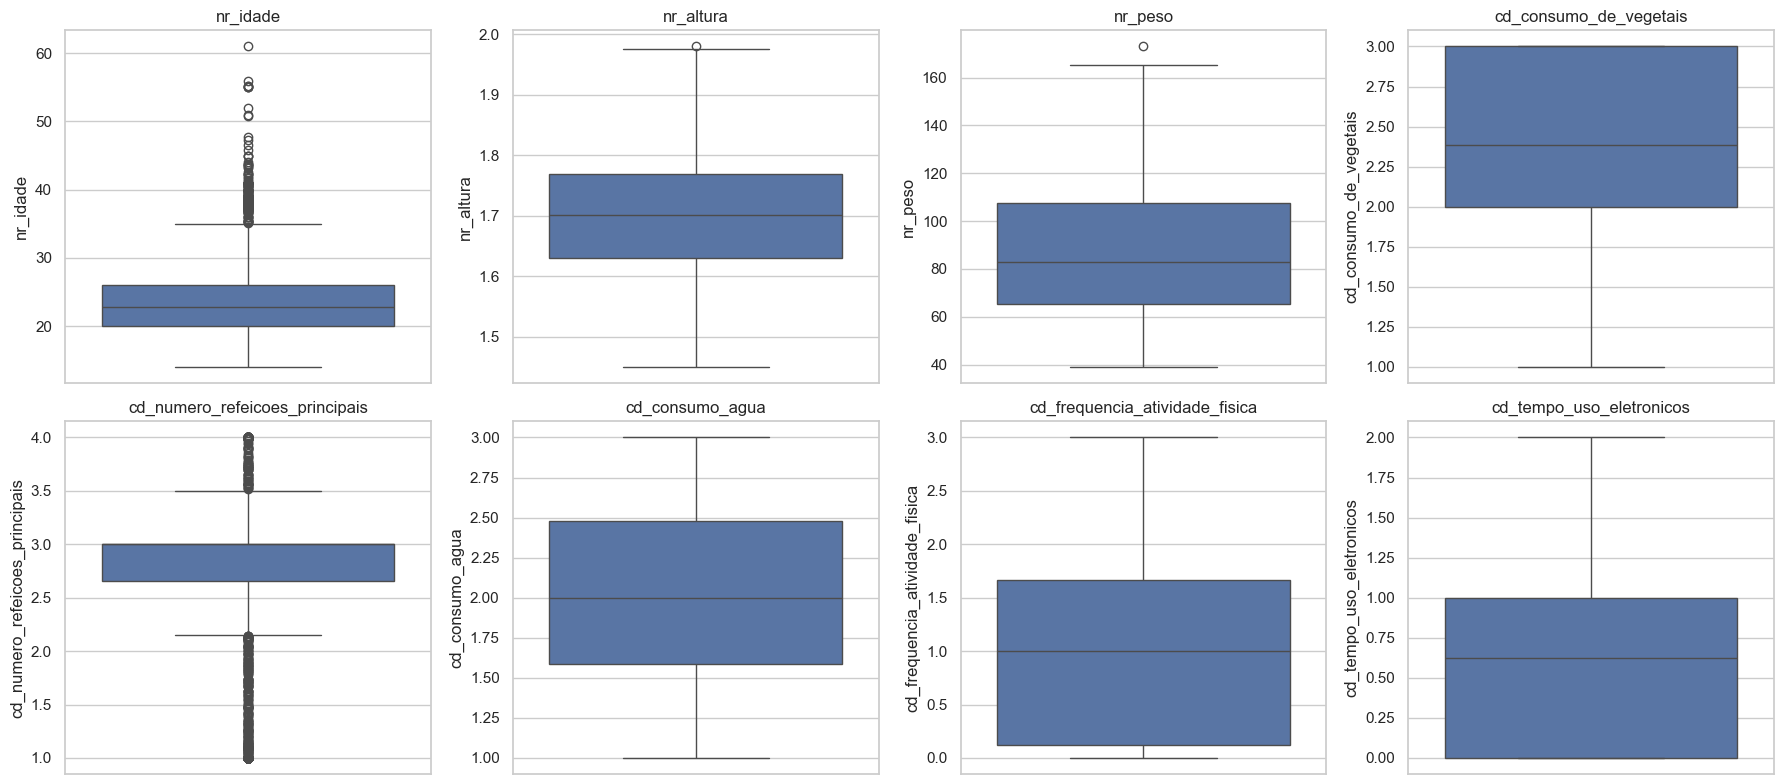

In [13]:
fig, eixos = plt.subplots(2, 4, figsize=(18, 8))
eixos = eixos.flatten()

for eixo, coluna in zip(eixos, COLUNAS_NUMERICAS):
    sns.boxplot(y=pacientes_obesidade[coluna], ax=eixo)
    eixo.set_title(coluna)

plt.tight_layout()
plt.show()

### 5.6 Matriz de correlação

Correlação de Pearson entre as variáveis numéricas, para identificar relações lineares fortes e possível multicolinearidade antes da modelagem.

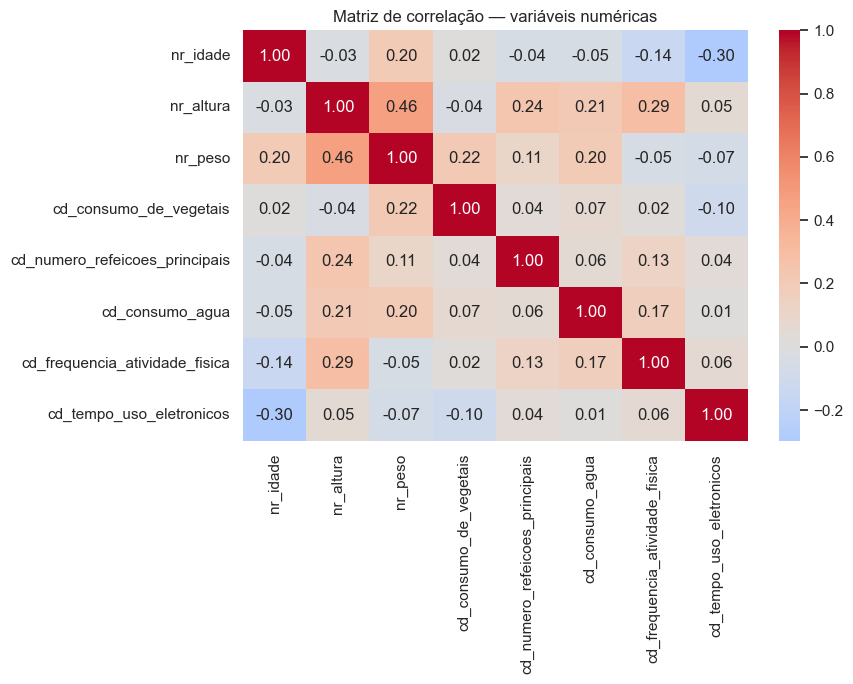

In [14]:
matriz_correlacao = pacientes_obesidade[COLUNAS_NUMERICAS].corr()

fig, eixo = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=eixo)
eixo.set_title("Matriz de correlação — variáveis numéricas")
plt.tight_layout()
plt.show()

## 6. Limpeza dos dados

Aqui tratamos os dois problemas de qualidade identificados na seção anterior (duplicatas exatas e ruído decimal nas variáveis ordinais) e, com os dados já tratados, avançamos para o cruzamento das variáveis de hábito.

### 6.1 Remoção de duplicatas exatas

In [15]:
pacientes_sem_duplicatas = remover_duplicatas_exatas(pacientes_obesidade)
len(pacientes_sem_duplicatas)

2087

### 6.2 Arredondamento das colunas ordinais

As colunas ordinais `cd_consumo_de_vegetais`, `cd_numero_refeicoes_principais`, `cd_consumo_agua`, `cd_frequencia_atividade_fisica` e `cd_tempo_uso_eletronicos` têm ruído decimal no arquivo original (ex.: 2.34 em vez de 2), embora representem escalas discretas segundo o dicionário de dados do projeto. Arredondamos essas colunas para inteiro antes de qualquer encoding ou modelagem, usando `arredondar_colunas_ordinais`.

In [16]:
pacientes_tratados = arredondar_colunas_ordinais(pacientes_sem_duplicatas, COLUNAS_ORDINAIS_ARREDONDAR)

pacientes_tratados[COLUNAS_ORDINAIS_ARREDONDAR].describe()

,cd_consumo_de_vegetais,cd_numero_refeicoes_principais,cd_consumo_agua,cd_frequencia_atividade_fisica,cd_tempo_uso_eletronicos
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,2.425970,2.703402,2.011500,1.009104,0.669861
std,0.585177,0.797108,0.685322,0.898712,0.673970
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,3.000000,2.000000,0.000000,0.000000
50%,2.000000,3.000000,2.000000,1.000000,1.000000
75%,3.000000,3.000000,2.000000,2.000000,1.000000
max,3.000000,4.000000,3.000000,3.000000,2.000000


### 6.3 Cruzamento das variáveis de hábito com a variável alvo

Analisamos como `fl_consumo_calorico_frequente`, `cd_consumo_de_vegetais`, `cd_frequencia_atividade_fisica`, `ds_consumo_alcool` e `ds_meio_transporte` se relacionam com o nível de obesidade. As categóricas (`fl_consumo_calorico_frequente`, `ds_consumo_alcool`, `ds_meio_transporte`) são vistas via percentual de cada nível de obesidade dentro de cada categoria de hábito; as ordinais (`cd_consumo_de_vegetais`, `cd_frequencia_atividade_fisica`, já arredondadas) via boxplot por classe.

Principais leituras do cruzamento:

- fl_consumo_calorico_frequente é o categórico com o gradiente mais limpo: entre quem responde "não", 52,7% está em Insufficient_Weight/Normal_Weight e só 7,8% nas três classes de Obesity_Type_; entre quem responde "sim", essa proporção se inverte (51,6% nas classes de obesidade). 
- ds_consumo_alcool não mostra um padrão monotônico (no tem mais casos em Obesity_Type_I do que Sometimes na mesma classe) e deve ser lido com cautela: a categoria Always tem apenas 1 paciente na base inteira e Frequently tem só 70 — os percentuais dessas categorias não são estatisticamente confiáveis e não devem ser tratados como tendência populacional. Por isso agrupamos Frequently e Always em uma única categoria em 7.2.3.
- ds_meio_transporte: Walking e Bike concentram ~56-57% dos casos em Normal_Weight. Mas Bike (n=7) e Motorbike (n=11) têm amostras pequenas demais para generalizar.
- cd_frequencia_atividade_fisica tem gradiente monotônico claro, como o fl_consumo_calorico_frequente.
- cd_consumo_de_vegetais, por outro lado, tem relação em U: mediana 3 tanto em Insufficient_Weight quanto em Obesity_Type_III (os dois extremos), caindo para 2 nas classes intermediárias.

Implicação para a modelagem: categorias com poucas observações (ds_consumo_alcool == "Always", ds_meio_transporte in ["Bike", "Motorbike"]) merecem atenção no encoding. Para ds_consumo_alcool, já resolvemos isso agrupando as categorias raras em 7.2.3.

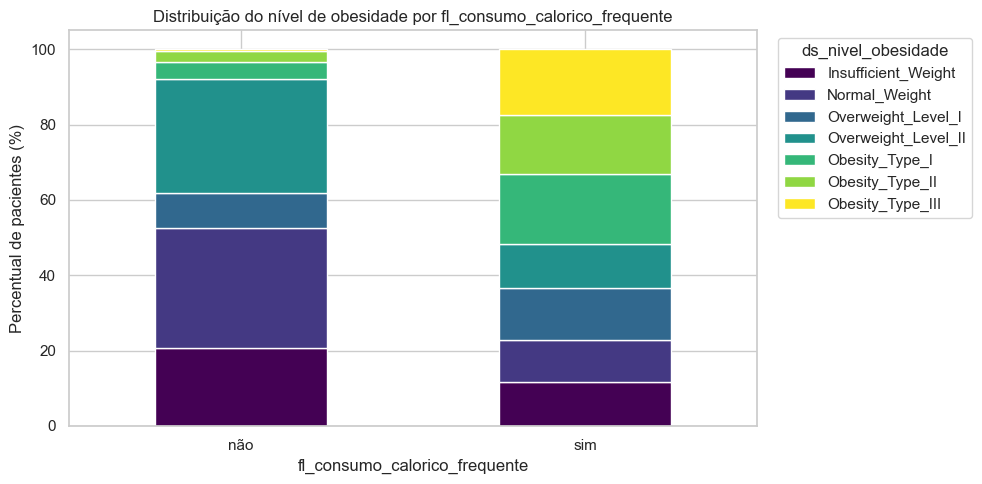

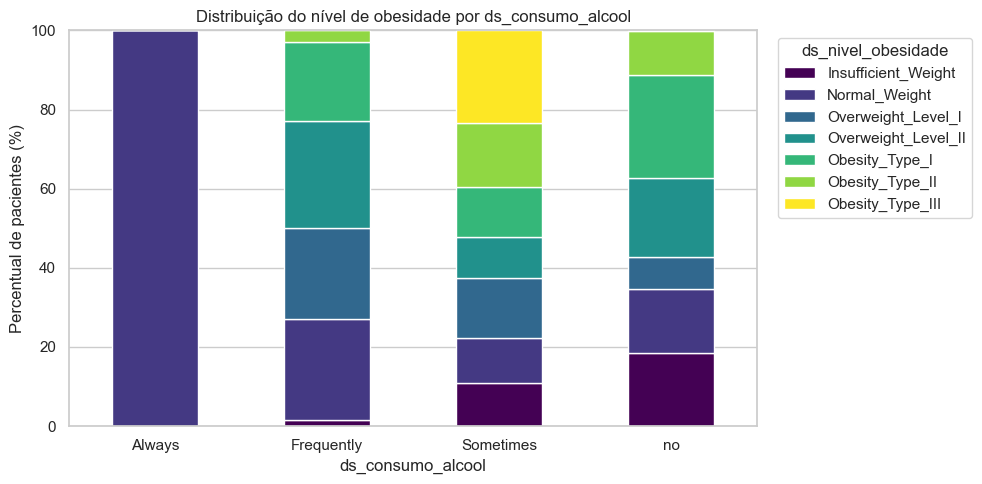

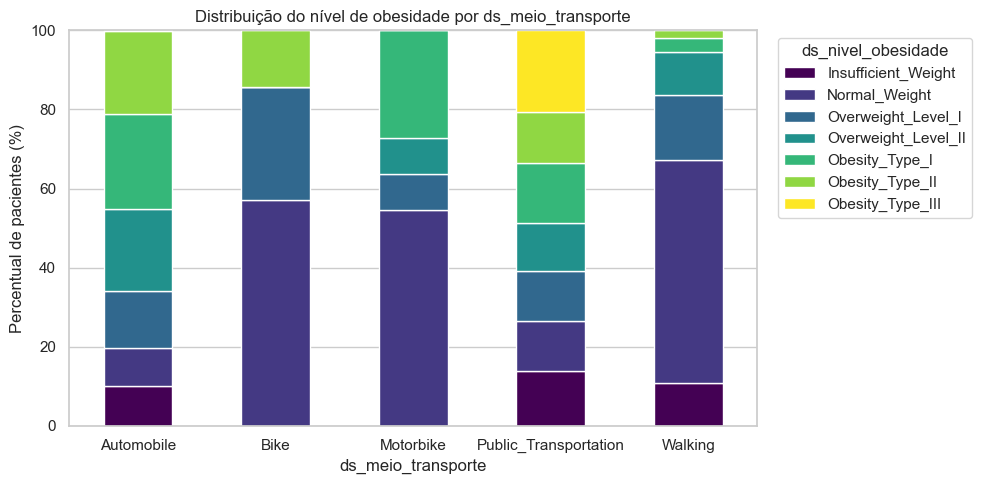

In [17]:
variaveis_habito_categoricas = ["fl_consumo_calorico_frequente", "ds_consumo_alcool", "ds_meio_transporte"]
MAPA_FLAG_LEGIVEL = {1: "sim", 0: "não"}

for coluna in variaveis_habito_categoricas:
    categoria_para_grafico = pacientes_tratados[coluna]
    if coluna.startswith("fl_"):
        categoria_para_grafico = categoria_para_grafico.map(MAPA_FLAG_LEGIVEL)

    tabela_cruzada = (
        pd.crosstab(categoria_para_grafico, pacientes_tratados["ds_nivel_obesidade"], normalize="index")
        .reindex(columns=ORDEM_NIVEIS_OBESIDADE)
        * 100
    )

    tabela_cruzada.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
    plt.title(f"Distribuição do nível de obesidade por {coluna}")
    plt.ylabel("Percentual de pacientes (%)")
    plt.xlabel(coluna)
    plt.xticks(rotation=0)
    plt.legend(title="ds_nivel_obesidade", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

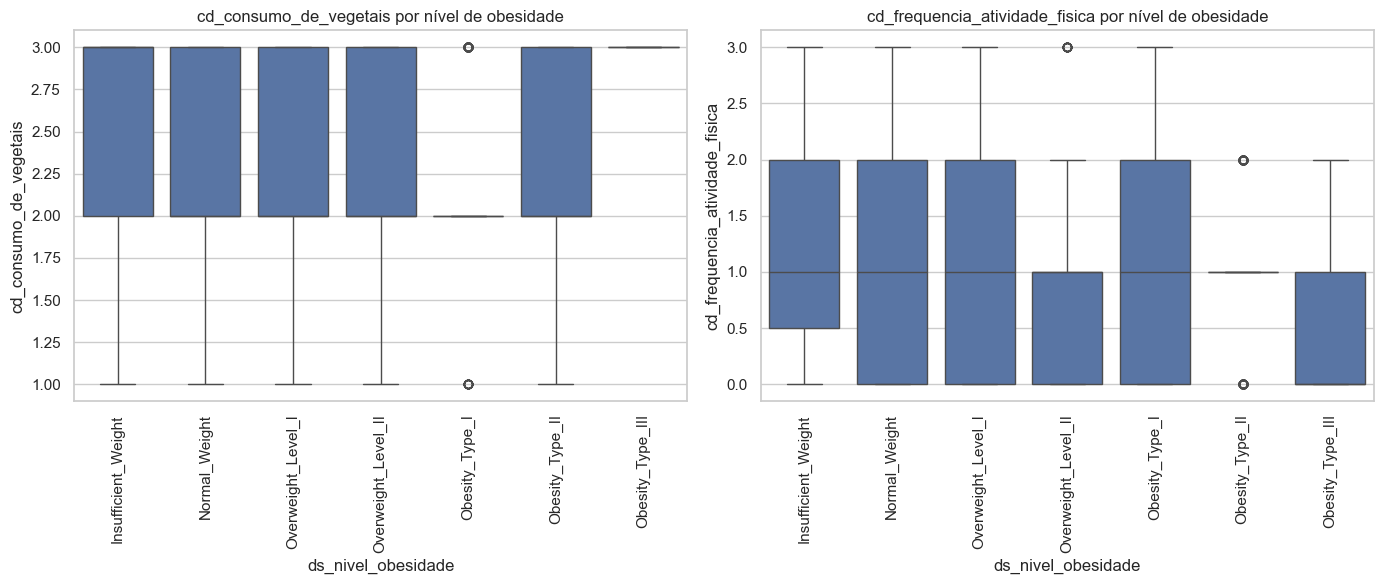

In [18]:
variaveis_habito_ordinais = ["cd_consumo_de_vegetais", "cd_frequencia_atividade_fisica"]

fig, eixos = plt.subplots(1, 2, figsize=(14, 6))

for eixo, coluna in zip(eixos, variaveis_habito_ordinais):
    sns.boxplot(data=pacientes_tratados, x="ds_nivel_obesidade", y=coluna, order=ORDEM_NIVEIS_OBESIDADE, ax=eixo)
    eixo.set_title(f"{coluna} por nível de obesidade")
    eixo.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## 7. Engenharia de atributos

### 7.1 IMC — verificação diagnóstica da derivação do alvo

Como o alvo deste dataset público (UCI *Estimation of obesity levels*) é conhecido por ser derivado de faixas de IMC, calculamos o IMC diretamente a partir de `nr_altura` e `nr_peso` e comparamos com as classes de `ds_nivel_obesidade` para confirmar essa hipótese antes da modelagem. Percebe-se que realmente há uma relação proporcional entre elas.

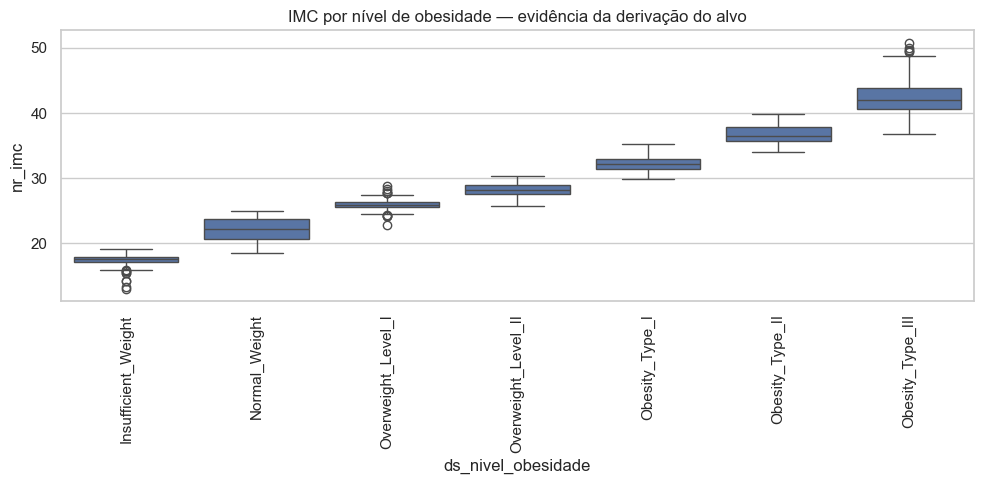

In [19]:
pacientes_tratados["nr_imc"] = pacientes_tratados["nr_peso"] / (pacientes_tratados["nr_altura"] ** 2)

fig, eixo = plt.subplots(figsize=(10, 5))
sns.boxplot(data=pacientes_tratados, x="ds_nivel_obesidade", y="nr_imc", order=ORDEM_NIVEIS_OBESIDADE, ax=eixo)
eixo.set_title("IMC por nível de obesidade — evidência da derivação do alvo")
eixo.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [20]:
faixas_imc_por_classe = (
    pacientes_tratados.groupby("ds_nivel_obesidade")["nr_imc"].agg(["min", "max", "mean"]).reindex(ORDEM_NIVEIS_OBESIDADE)
)
faixas_imc_por_classe

,min,max,mean
ds_nivel_obesidade,,,
Insufficient_Weight,12.998685,19.082206,17.390730
Normal_Weight,18.491124,24.913495,22.007841
Overweight_Level_I,22.826739,28.769607,25.956179
Overweight_Level_II,25.713513,30.362877,28.215232
Obesity_Type_I,29.911958,35.171095,32.255636
Obesity_Type_II,34.048509,39.786652,36.723424
Obesity_Type_III,36.774400,50.811753,42.273746


### 7.2 Novas features comportamentais

Todas construídas a partir de variáveis de hábito, comportamento e demografia — nenhuma delas usa `nr_altura`, `nr_peso` ou o IMC calculado acima, justamente para o modelo prever de acordo com os padrões de vida dos pacientes, em vez de apenas replicar um cálculo IMC (e chegar a uma acurácia alta, mas vazia).

#### 7.2.1 `fl_transporte_ativo`

Binária: 1 se o meio de transporte habitual (`ds_meio_transporte`) for `Walking` ou `Bike`, 0 caso contrário. Resume o sinal mais relevante de `ds_meio_transporte` (deslocamento ativo vs. passivo) em uma única variável. Tentativa de reduzir ruído amostral pela quantidade pequena de registros por categoria.

In [21]:
pacientes_tratados = criar_features_comportamentais(pacientes_tratados)

(pacientes_tratados.groupby("ds_nivel_obesidade")["fl_transporte_ativo"].mean().reindex(ORDEM_NIVEIS_OBESIDADE) * 100).rename(
    "percentual_transporte_ativo"
)

ds_nivel_obesidade
Insufficient_Weight     2.247191
Normal_Weight          12.411348
Overweight_Level_I      3.985507
Overweight_Level_II     2.068966
Obesity_Type_I          0.569801
Obesity_Type_II         0.673401
Obesity_Type_III        0.000000
Name: percentual_transporte_ativo, dtype: float64

#### 7.2.2 `ds_faixa_etaria`

Categorização clínica de `nr_idade` em quatro faixas (`adolescente`, `adulto_jovem`, `adulto`, `meia_idade`). Não deve adicionar poder preditivo além do já capturado por `nr_idade` contínua em modelos de árvore, mas facilita a leitura do perfil de pacientes para a equipe médica.

In [22]:
pacientes_tratados["ds_faixa_etaria"].value_counts().reindex(
    ["adolescente", "adulto_jovem", "adulto", "meia_idade"]
)

ds_faixa_etaria
adolescente      407
adulto_jovem    1324
adulto           342
meia_idade        14
Name: count, dtype: int64

#### 7.2.3 `ds_consumo_alcool_agrupado`

Como visto em 6.3, `ds_consumo_alcool` tem duas categorias com amostra muito pequena (`Frequently` com 70 casos e `Always` com apenas 1 caso na base inteira), o que deixa os percentuais dessas classes pouco confiáveis e arriscado para o encoding (o modelo pode memorizar ruído amostral em vez de padrão real). Agrupamos `Frequently` e `Always` em uma única categoria `consumo_frequente_ou_mais`, mantendo `no` e `Sometimes` como estão.

In [23]:
pacientes_tratados["ds_consumo_alcool_agrupado"].value_counts()

ds_consumo_alcool_agrupado
Sometimes                    1380
no                            636
consumo_frequente_ou_mais      71
Name: count, dtype: int64

## 8. Salvando a Base Silver

In [24]:
CAMINHO_DADOS_TRATADOS = "../data/silver/obesity_tratado.csv"
pacientes_tratados.to_csv(CAMINHO_DADOS_TRATADOS, index=False)

## 9. Conclusões - Análise Exploratória e Engenharia de Atributos

**Variável alvo**
- As 7 classes de `ds_nivel_obesidade` têm contagens entre 272 (`Insufficient_Weight`) e 351 (`Obesity_Type_I`) pacientes — um desbalanceamento leve (razão ≈ 1,3x entre a maior e a menor classe), não severo. Ainda assim, split estratificado e métricas como F1-macro (além de accuracy) serão realizados na etapa de modelagem.

**Distribuições e correlações**
- `nr_idade` é concentrada em adultos jovens (mediana ≈ 23 anos, faixa 14–61), com leve assimetria à direita. O único paciente com mais de 60 anos (61 anos) não foi tratado como outlier a remover: é um valor plausível (IMC coerente com `Normal_Weight`) e está no topo de uma cauda contínua, não isolado.
- `nr_altura` e `nr_peso` têm distribuição aproximadamente contínua e sem outliers extremos aparentes.
- Na matriz de correlação original, `nr_peso` é a variável mais correlacionada com `nr_altura` (correlação moderada, ~0,46); as demais variáveis numéricas têm correlação fraca com `nr_peso`.

**Hábitos vs. nível de obesidade**
- `fl_consumo_calorico_frequente` (consumo frequente de alimentos calóricos = "yes") aparece proporcionalmente mais associado às classes de sobrepeso/obesidade mais altas.
- `ds_meio_transporte`: pacientes que usam `Automobile` concentram-se mais nas classes de obesidade mais altas, enquanto `Walking`/`Bike` aparecem mais entre `Insufficient_Weight`/`Normal_Weight`.
- `cd_consumo_de_vegetais` e `cd_frequencia_atividade_fisica` (após arredondamento) mostram tendências visíveis nos boxplots por classe, mas com sobreposição considerável entre grupos.
- `ds_consumo_alcool` tem categorias muito desbalanceadas (poucos casos em "Always"), o que deve ser considerado ao interpretar esse cruzamento — por isso criamos `ds_consumo_alcool_agrupado` em 7.2.3.

**Achado central: o alvo é derivado de IMC**
- Ao calcular `IMC = nr_peso / nr_altura²`, as faixas de IMC por classe de `ds_nivel_obesidade` praticamente não se sobrepõem (ex.: `Insufficient_Weight` ≈ 13–19, `Normal_Weight` ≈ 18,5–24,9, `Obesity_Type_III` ≈ 36,8–50,8).

**Features comportamentais e de agrupamento**
- `fl_transporte_ativo` é o achado mais forte entre as novas features: cai de forma praticamente monotônica de ~12,4% em `Normal_Weight` para 0% em `Obesity_Type_III`. Sinal claro e de fácil leitura clínica.
- `ds_faixa_etaria`: o grupo `meia_idade` tem apenas 14 pacientes — qualquer leitura sobre essa faixa deve considerar o tamanho amostral pequeno.
- `ds_consumo_alcool_agrupado` resolve o problema de categorias raras identificado em 6.3 (`Always` com 1 caso, `Frequently` com 70), reduzindo o risco de o modelo memorizar ruído amostral em categorias praticamente sem representação.

**Decisão sobre manter ou não `nr_altura`/`nr_peso`/IMC no modelo**

Como o alvo é essencialmente uma função determinística de `nr_altura` e `nr_peso`, incluir essas duas colunas (ou qualquer derivada direta, como o próprio IMC) tende a produzir um modelo com accuracy muito alta, mas que apenas reaprendeu a fórmula do IMC — sem agregar valor clínico sobre hábitos alimentares e atividade física, que é o pedido de negócio do hospital. Substituir `nr_altura`/`nr_peso` por IMC não resolve esse problema: pelo contrário, concentra a mesma informação circular em uma única variável ainda mais determinística.

Próximos passos para a modelagem:
1. Treinar e documentar dois modelos: 
(a) um modelo de referência com `nr_altura`/`nr_peso`/IMC, servindo de "teto" de performance e checagem de sanidade.
(b) um modelo de hábitos e perfil, sem `nr_altura`, `nr_peso` ou IMC, usando as variáveis de hábito originais mais as novas features.
2. Deixar essa decisão e sua justificativa explícitas em markdown no notebook de modelagem, evitando apresentar a exclusão (ou inclusão) de `nr_altura`/`nr_peso`/IMC como uma escolha técnica neutra.